In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#$matplotlib inline

In [2]:
df = pd.read_csv('weight-height.csv')
df.head(5)

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No


In [3]:
df.columns

Index(['Height', 'Weight', 'Gender', 'Age', 'BMI', 'Weight_Category',
       'Activity_Level', 'Systolic_BP', 'Diastolic_BP', 'BP_Category',
       'Cholesterol', 'Cholesterol_Category', 'Smoker'],
      dtype='object')

SLR

In [4]:
df1 = df[['Height', 'Weight']] 
df1.head(5)

,Height,Weight
0,161.72,53.80
1,171.99,76.12
2,179.51,87.38
3,179.68,74.28
4,162.94,62.76


In [5]:
df1.describe()

,Height,Weight
count,50000.000000,50000.000000
mean,168.791384,67.349698
std,9.886864,11.206605
min,145.000000,45.000000
25%,161.540000,59.080000
50%,168.450000,66.570000
75%,175.730000,75.020000
max,200.000000,111.330000


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  50000 non-null  float64
 1   Weight  50000 non-null  float64
dtypes: float64(2)
memory usage: 781.4 KB


{'whiskers': [<matplotlib.lines.Line2D at 0x1c26b6596a0>,
 'caps': [<matplotlib.lines.Line2D at 0x1c26b659940>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c26b659550>,
 'medians': [<matplotlib.lines.Line2D at 0x1c26b659be0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1c26b659d30>,
 'means': []}

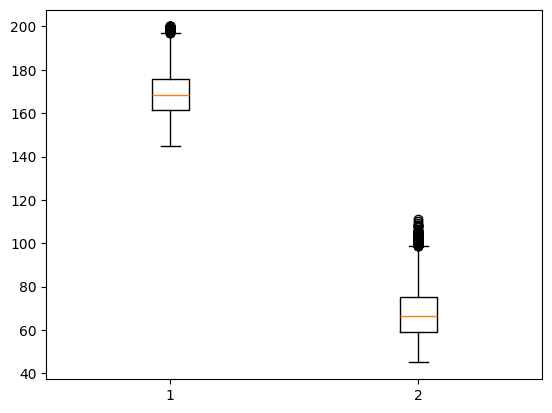

In [7]:
plt.boxplot(df1)

In [8]:
def filter_outlier(df1, column):
    Q1 = df1[column].quantile(0.25)
    Q3 = df1[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    return df1[(df1[column] >= lower_bound) &(df1[column] <= upper_bound)]
df_c  = filter_outlier(df1, 'Weight')
df_c  = filter_outlier(df_c, 'Height')
print(f'Rows Removed:{len(df1) - len(df_c)}')

Rows Removed:248


{'whiskers': [<matplotlib.lines.Line2D at 0x1c26b802cf0>,
 'caps': [<matplotlib.lines.Line2D at 0x1c26b802f90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c26b802ba0>,
 'medians': [<matplotlib.lines.Line2D at 0x1c26b803230>,
 'fliers': [<matplotlib.lines.Line2D at 0x1c26b803380>,
 'means': []}

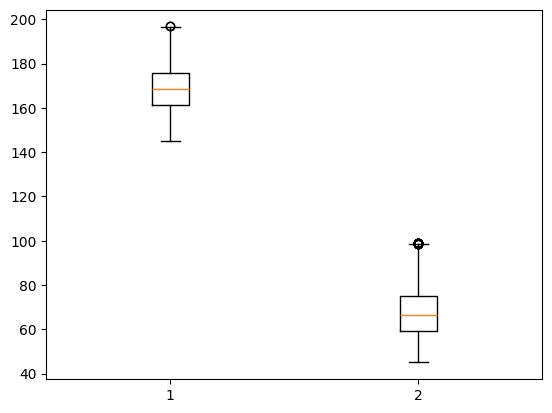

In [9]:
plt.boxplot(df_c)

In [10]:
df_c.isna().count()

Height    49752
Weight    49752
dtype: int64

In [11]:
x = df_c[['Weight']]
y = df_c['Height']

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=30, random_state=42, shuffle=True)

In [13]:
x_test.shape, x_train.shape

((30, 1), (49722, 1))

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [126]:
slr.predict([[53.8]])

array([598.72689054])

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
y_pred = slr.predict(x_test_scaled)
y_pred_tr = slr.predict(x_train_scaled)

#Traiing Metrics
MAE_tr = mean_absolute_error(y_train, y_pred_tr)
MSE_tr = mean_squared_error(y_train, y_pred_tr)
R2_tr = r2_score(y_train, y_pred_tr)
print(f'the metrics are as follows> MSE: {MSE_tr}; MAE: {MAE_tr}; R2_Score: {R2_tr}')

#Testing Metrics
MAE_te = mean_absolute_error(y_test, y_pred)
MSE_te = mean_squared_error(y_test, y_pred)
R2_te = r2_score(y_test, y_pred)
print(f'the metrics are as follows> MSE: {MSE_te}; MAE: {MAE_te}; R2_Score: {R2_te}')

the metrics are as follows> MSE: 31.466895858825144; MAE: 4.480326179638749; R2_Score: 0.670031525915795
the metrics are as follows> MSE: 34.3283417958256; MAE: 4.412490773325667; R2_Score: 0.594876604631009


In [17]:
#confirming my r score through cross validation
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(slr, x_train_scaled, y_train, cv = 5, scoring='r2')
print(f'scores for each fold: {cv_score}')
print(f'Average R2 scores: {np.mean(cv_score)}')
print(f's=Standard Deviation: {np.std(cv_score)}')

scores for each fold: [0.66616045 0.67182754 0.67138382 0.6726002  0.667839  ]
Average R2 scores: 0.6699622026449958
s=Standard Deviation: 0.0025068245139258046


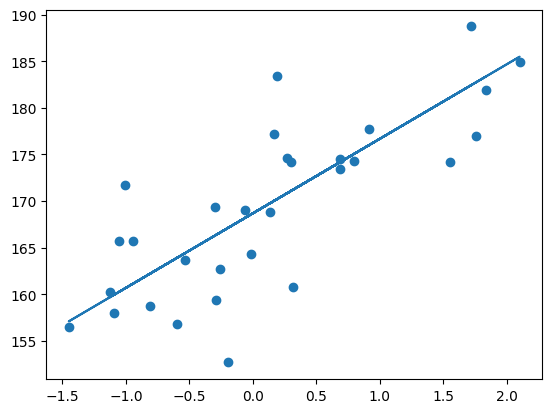

In [18]:
plt.scatter(x_test_scaled,y_test)
plt.plot(x_test_scaled, y_pred)


Assumptions

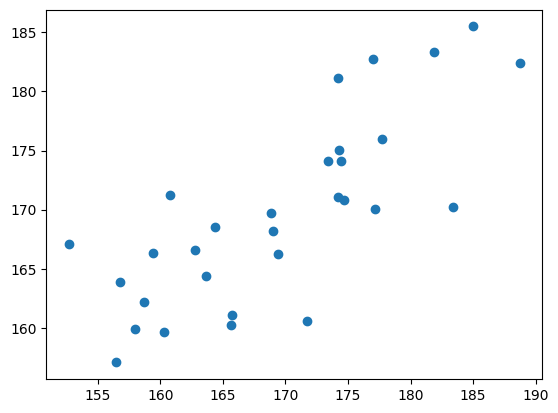

In [19]:
plt.scatter(y_test,y_pred)

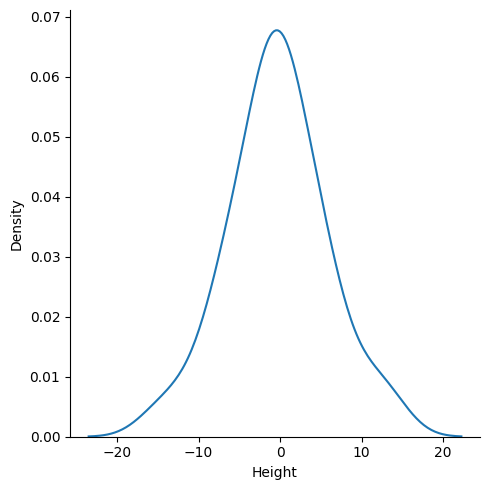

In [20]:
import seaborn as sns
residuals = y_test - y_pred
sns.displot(residuals, kind='kde')

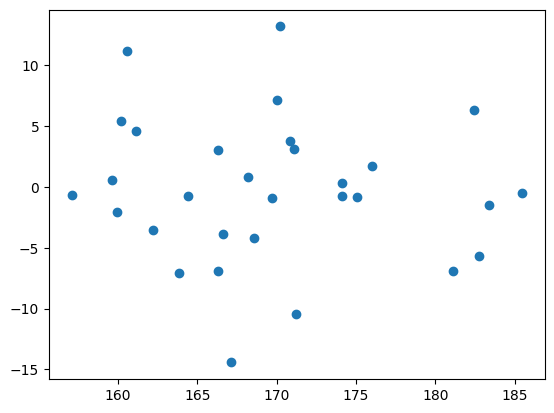

In [21]:
plt.scatter(y_pred, residuals)

In [22]:
slr.predict(scaler.transform([[53.4]]))

c:\Users\HP USER\Desktop\VS Code\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([158.65711545])

SLR using Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import seaborn as sns

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=30, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('Regression', LinearRegression())
    ])
pipe.fit(x_train, y_train)
pipe.predict([[53.4]])

cross_val_score(slr, x_train_scaled, y_train, cv = 5, scoring='neg_mean_squared_error')


c:\Users\HP USER\Desktop\VS Code\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-31.55918532, -31.56229082, -31.28770903, -31.39519994,
       -31.54359348])

Multiple Linear Regression

In [24]:
df.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No


In [25]:
df2 = df[['Height', 'Weight', "Age", 'Gender', 'BMI']]
df2.head(5)

,Height,Weight,Age,Gender,BMI
0,161.72,53.80,19,Female,20.57
1,171.99,76.12,56,Male,25.73
2,179.51,87.38,69,Male,27.12
3,179.68,74.28,20,Male,23.01
4,162.94,62.76,54,Female,23.64


In [26]:
df2['Gender'] = df2['Gender'].map({'Male': 0, 'Female': 1})
df2.head()

C:\Users\HP USER\AppData\Local\Temp\ipykernel_20712\2891738592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Gender'] = df2['Gender'].map({'Male': 0, 'Female': 1})


,Height,Weight,Age,Gender,BMI
0,161.72,53.80,19,1,20.57
1,171.99,76.12,56,0,25.73
2,179.51,87.38,69,0,27.12
3,179.68,74.28,20,0,23.01
4,162.94,62.76,54,1,23.64


<Axes: >

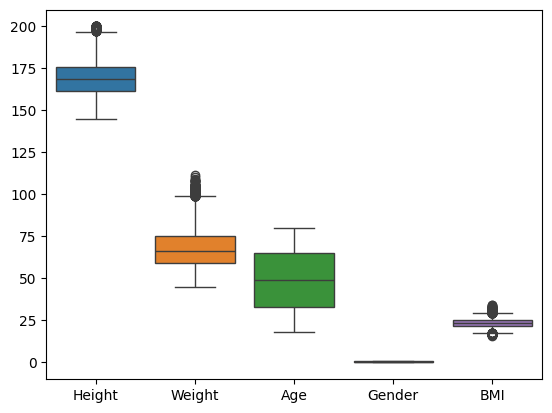

In [27]:
sns.boxplot(df2)

In [28]:
def filter_outlier(df2, column):
    Q1 = df2[column].quantile(0.25)
    Q3 = df2[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    return df2[(df2[column] >= lower_bound) &(df2[column] <= upper_bound)]
df_s  = filter_outlier(df2, 'Weight')
df_s  = filter_outlier(df_s, 'Height')
df_s  = filter_outlier(df_s, 'BMI')
print(f'Rows Removed:{len(df2) - len(df_s)}')



Rows Removed:575


<Axes: >

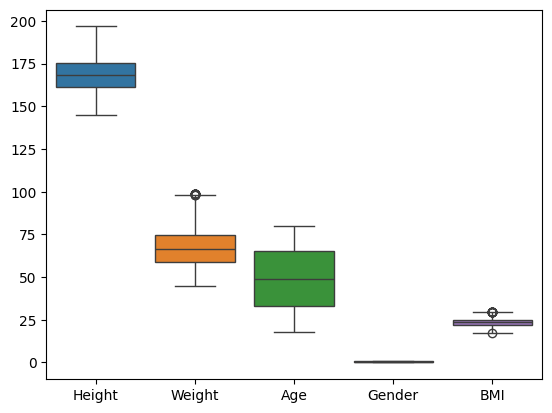

In [29]:
sns.boxplot(df_s)

In [30]:
#Checking for Multicollinearity
df_s.corr()

,Height,Weight,Age,Gender,BMI
Height,1.000000,0.826168,-0.011043,-0.656592,0.199196
Weight,0.826168,1.000000,0.202192,-0.615794,0.712184
Age,-0.011043,0.202192,1.000000,0.014485,0.364345
Gender,-0.656592,-0.615794,0.014485,1.000000,-0.260601
BMI,0.199196,0.712184,0.364345,-0.260601,1.000000


In [31]:
y = df_s.iloc[:,-1:]
x = df_s.iloc[:,:4]
y.head(3), x.head(3)

(     BMI
 0  20.57
 1  25.73
 2  27.12,
    Height  Weight  Age  Gender
 0  161.72   53.80   19       1
 1  171.99   76.12   56       0
 2  179.51   87.38   69       0)

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Training and Testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.30, random_state= 42)

#Standadization
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

#multiple Linear Regression
mlr = LinearRegression()
mlr.fit(x_train_s, y_train)
#mlr.predict(x_test)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
y_pred = mlr.predict(x_test_s)
y_pred_tr = mlr.predict(x_train_s)

#Traiing Metrics
MAE_tr = mean_absolute_error(y_train, y_pred_tr)
MSE_tr = mean_squared_error(y_train, y_pred_tr)
R2_tr = r2_score(y_train, y_pred_tr)
print(f'the metrics are as follows> MSE: {MSE_tr}; MAE: {MAE_tr}; R2_Score: {R2_tr}')

#Testing Metrics
MAE_te = mean_absolute_error(y_test, y_pred)
MSE_te = mean_squared_error(y_test, y_pred)
R2_te = r2_score(y_test, y_pred)
print(f'the metrics are as follows> MSE: {MSE_te}; MAE: {MAE_te}; R2_Score: {R2_te}')

the metrics are as follows> MSE: 0.07589001595969622; MAE: 0.20145678650374133; R2_Score: 0.9842188690624412
the metrics are as follows> MSE: 0.07539500301578776; MAE: 0.20108850435499628; R2_Score: 0.9847282809149278


In [34]:
#confirming my r score through cross validation
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(mlr, x_train_s, y_train, cv = 5, scoring='r2')
print(f'scores for each fold: {cv_score}')
print(f'Average R2 scores: {np.mean(cv_score)}')
print(f'Standard Deviation: {np.std(cv_score)}')

scores for each fold: [0.98395884 0.98464137 0.98435892 0.98344992 0.9846497 ]
Average R2 scores: 0.9842117478633693
Standard Deviation: 0.000456593537557803


In [35]:
x_test_s.shape, y_test.shape

((14828, 4), (14828, 1))

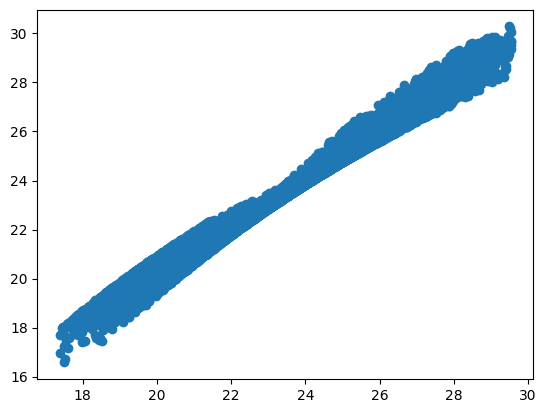

In [36]:
plt.scatter(y_test,y_pred)

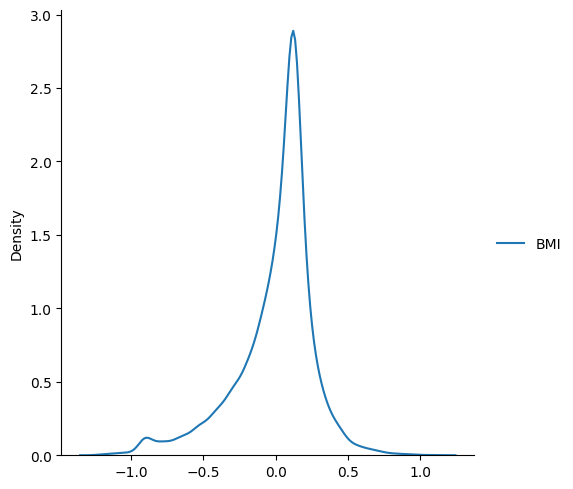

In [37]:
import seaborn as sns
residuals = y_test - y_pred
sns.displot(residuals, kind='kde')

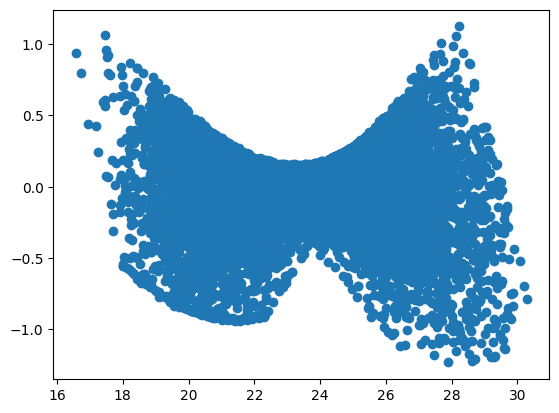

In [38]:
plt.scatter(y_pred, residuals)

Logistic Regression

In [54]:
df.head(4)

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,...,Cholesterol_Category,Smoker,BP_Score,BMI_Score,CC_Score,Smoker_score,Activity_score,Age_score,Health_Score,Health_Risk
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,...,Normal,No,2,0,0,0,0.5,0,2.5,0
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,...,Normal,No,1,1,0,0,0.5,2,4.5,1
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,...,Borderline,No,1,1,1,0,0.5,2,5.5,1
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,...,Borderline,No,0,0,1,0,0.0,0,1.0,0


In [78]:

def cc_score(cc):
    if cc == 'Normal':
        return 0
    elif cc == 'Elevated':
        return 1
    else:
        return 2
df['BP'] = df['BP_Category'].apply(cc_score)

df['Smoker_'] = df['Smoker'].apply(lambda x: 1 if x.lower() == 'yes' else 0)
df['Gender_'] = df['Gender'].apply(lambda x: 1 if x.lower() == 'male' else 0)
def activity_score(act):
    if act == 'Very Active':
        return 0
    elif act == 'Moderately Active':
        return 1
    elif act == 'Lightly Active':
        return 2
    else:
        return 3
df['Activity'] = df['Activity_Level'].apply(activity_score)

{'whiskers': [<matplotlib.lines.Line2D at 0x1c20b296a50>,
 'caps': [<matplotlib.lines.Line2D at 0x1c20b296cf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c20b296900>,
 'medians': [<matplotlib.lines.Line2D at 0x1c20b296f90>,
 'fliers': [<matplotlib.lines.Line2D at 0x1c20b2970e0>,
 'means': []}

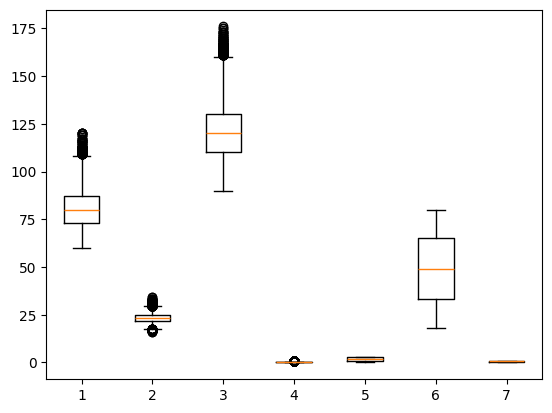

In [120]:
plt.boxplot(X)

In [121]:
#X = df[['Diastolic_BP', 'BMI', 'Systolic_BP', 'Smoker_', 'Activity', 'Age', 'Gender_']]# 'Health_Score']]
#Y = df['BP']
def filter_outlier(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    return df[(df[column] >= lower_bound) &(df[column] <= upper_bound)]
df_l  = filter_outlier(df, 'Diastolic_BP')
df_l  = filter_outlier(df_l, 'Systolic_BP')
df_l  = filter_outlier(df_l, 'BMI')
print(f'Rows Removed:{len(df) - len(df_l)}')



Rows Removed:630


In [122]:
X = df_l[['Diastolic_BP', 'BMI', 'Systolic_BP', 'Smoker_', 'Activity', 'Age', 'Gender_']]# 'Health_Score']]
Y = df_l['BP']
#X = df[['BP_Score', 'BMI_Score', 'CC_Score', 'Smoker_score', 'Activity_score', 'Age_score']]# 'Health_Score']]
#Y = df['Health_Risk']

In [123]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

#Training and Testing
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size =0.30, random_state= 42)

#Standadization
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

#multiple Logistic Regression
model = LogisticRegression()
CV = StratifiedKFold()
penalty = ['l1', 'l2', 'elasticnet']
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'] 
c = [100, 10, 1.0, 0.1, 0.01]
multi_class = ['auto', 'ovr', 'multinomial']
params = dict(penalty = penalty, C = c, solver = solver, multi_class = multi_class)

#grid search
grid = GridSearchCV(estimator = model, param_grid = params, cv= CV, scoring= 'accuracy')
grid.fit(x_train_s, y_train)

grid.param_grid

c:\Users\HP USER\Desktop\VS Code\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\HP USER\Desktop\VS Code\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\HP USER\Desktop\VS Code\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\HP 

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['lbfgs',
  'liblinear',
  'newton-cg',
  'newton-cholesky',
  'sag',
  'saga'],
 'multi_class': ['auto', 'ovr', 'multinomial']}

In [124]:
grid.best_estimator_, grid.best_score_

(LogisticRegression(C=0.1, multi_class='auto', penalty='l1', solver='liblinear'),
 np.float64(0.7621458736943787))

In [125]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
y_pred = grid.predict(x_test_s)
y_pred_tr = grid.predict(x_train_s)

#Traiing Metrics
MAE_tr = mean_absolute_error(y_train, y_pred_tr)
MSE_tr = mean_squared_error(y_train, y_pred_tr)
R2_tr = r2_score(y_train, y_pred_tr)
print(f'the metrics are as follows> MSE: {MSE_tr}; MAE: {MAE_tr}; R2_Score: {R2_tr}')

#Testing Metrics
MAE_te = mean_absolute_error(y_test, y_pred)
MSE_te = mean_squared_error(y_test, y_pred)
R2_te = r2_score(y_test, y_pred)
print(f'the metrics are as follows> MSE: {MSE_te}; MAE: {MAE_te}; R2_Score: {R2_te}')

the metrics are as follows> MSE: 0.2394455858097746; MAE: 0.23851963309123528; R2_Score: 0.5031235263907814
the metrics are as follows> MSE: 0.24434541894537842; MAE: 0.24340017554520288; R2_Score: 0.5019139247637303


In [140]:
df.groupby('BP_Category')['Systolic_BP'].agg(['min', 'max']).sort_values('min')

,min,max
BP_Category,,
Elevated,90,139
High,90,176
Normal,90,119
